In [95]:
import pandas as pd
import numpy as np


In [96]:
data=pd.read_csv("heart.csv")

In [97]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [98]:
data.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [99]:
data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [100]:
#no need for encoding categorical features

In [101]:
#normalization 

In [102]:
from sklearn.preprocessing import StandardScaler

FS=["age", "trestbps", "chol", "thalach", "oldpeak"]

data[FS]=StandardScaler().fit_transform(data[FS])

data[FS].head()

,age,trestbps,chol,thalach,oldpeak
0,-0.268437,-0.377636,-0.659332,0.821321,-0.060888
1,-0.158157,0.479107,-0.833861,0.255968,1.727137
2,1.716595,0.764688,-1.396233,-1.048692,1.301417
3,0.724079,0.936037,-0.833861,0.516900,-0.912329
4,0.834359,0.364875,0.930822,-1.874977,0.705408


In [103]:
data[FS].head()

,age,trestbps,chol,thalach,oldpeak
0,-0.268437,-0.377636,-0.659332,0.821321,-0.060888
1,-0.158157,0.479107,-0.833861,0.255968,1.727137
2,1.716595,0.764688,-1.396233,-1.048692,1.301417
3,0.724079,0.936037,-0.833861,0.516900,-0.912329
4,0.834359,0.364875,0.930822,-1.874977,0.705408


In [104]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,-0.268437,1,0,-0.377636,-0.659332,0,1,0.821321,0,-0.060888,2,2,3,0
1,-0.158157,1,0,0.479107,-0.833861,1,0,0.255968,1,1.727137,0,0,3,0
2,1.716595,1,0,0.764688,-1.396233,0,1,-1.048692,1,1.301417,0,0,3,0
3,0.724079,1,0,0.936037,-0.833861,0,1,0.516900,0,-0.912329,2,1,3,0
4,0.834359,0,0,0.364875,0.930822,1,1,-1.874977,0,0.705408,1,3,2,0


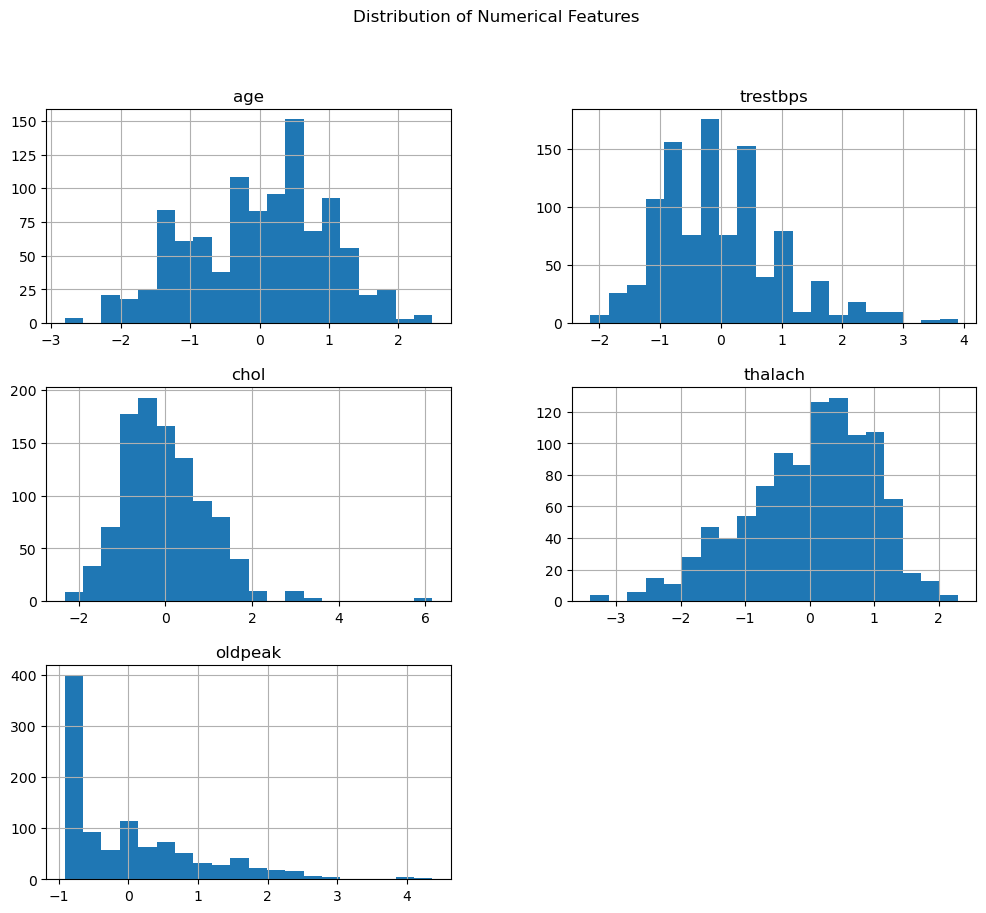

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot histograms for numerical features
FS = ["age", "trestbps", "chol", "thalach", "oldpeak"]
data[FS].hist(bins=20, figsize=(12, 10))
plt.suptitle("Distribution of Numerical Features")
plt.show()

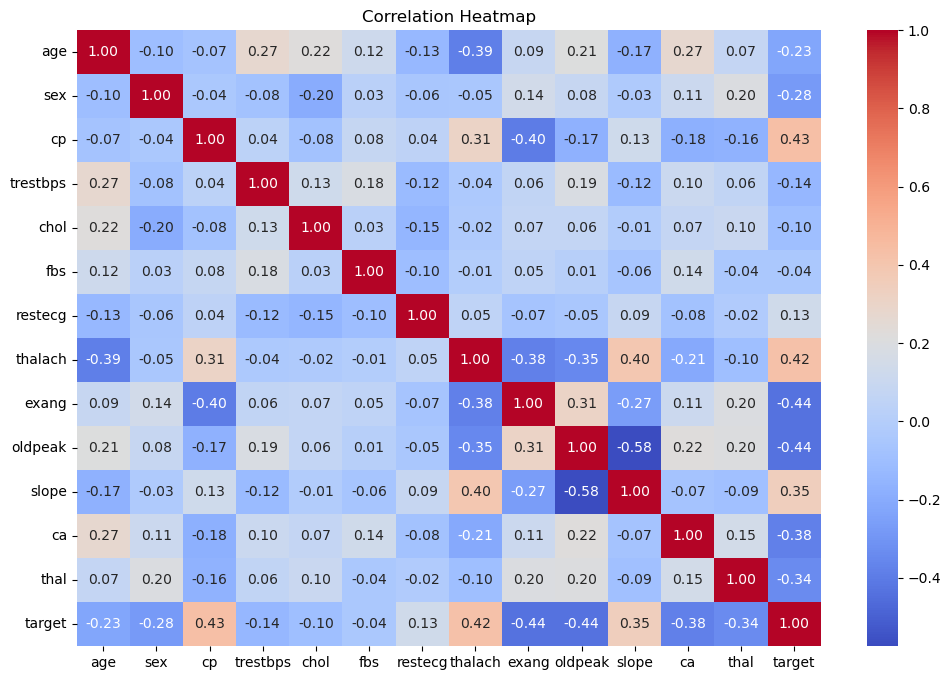

In [106]:
# Calculate correlation matrix
correlation_matrix = data.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

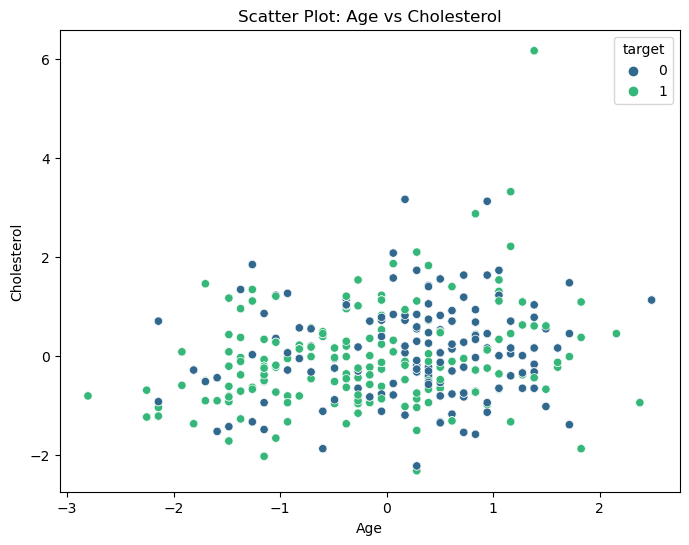

In [107]:
# Scatter plot for age vs chol
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data["age"], y=data["chol"], hue=data["target"], palette="viridis")
plt.title("Scatter Plot: Age vs Cholesterol")
plt.xlabel("Age")
plt.ylabel("Cholesterol")
plt.show()

C:\Users\Admin\anaconda\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


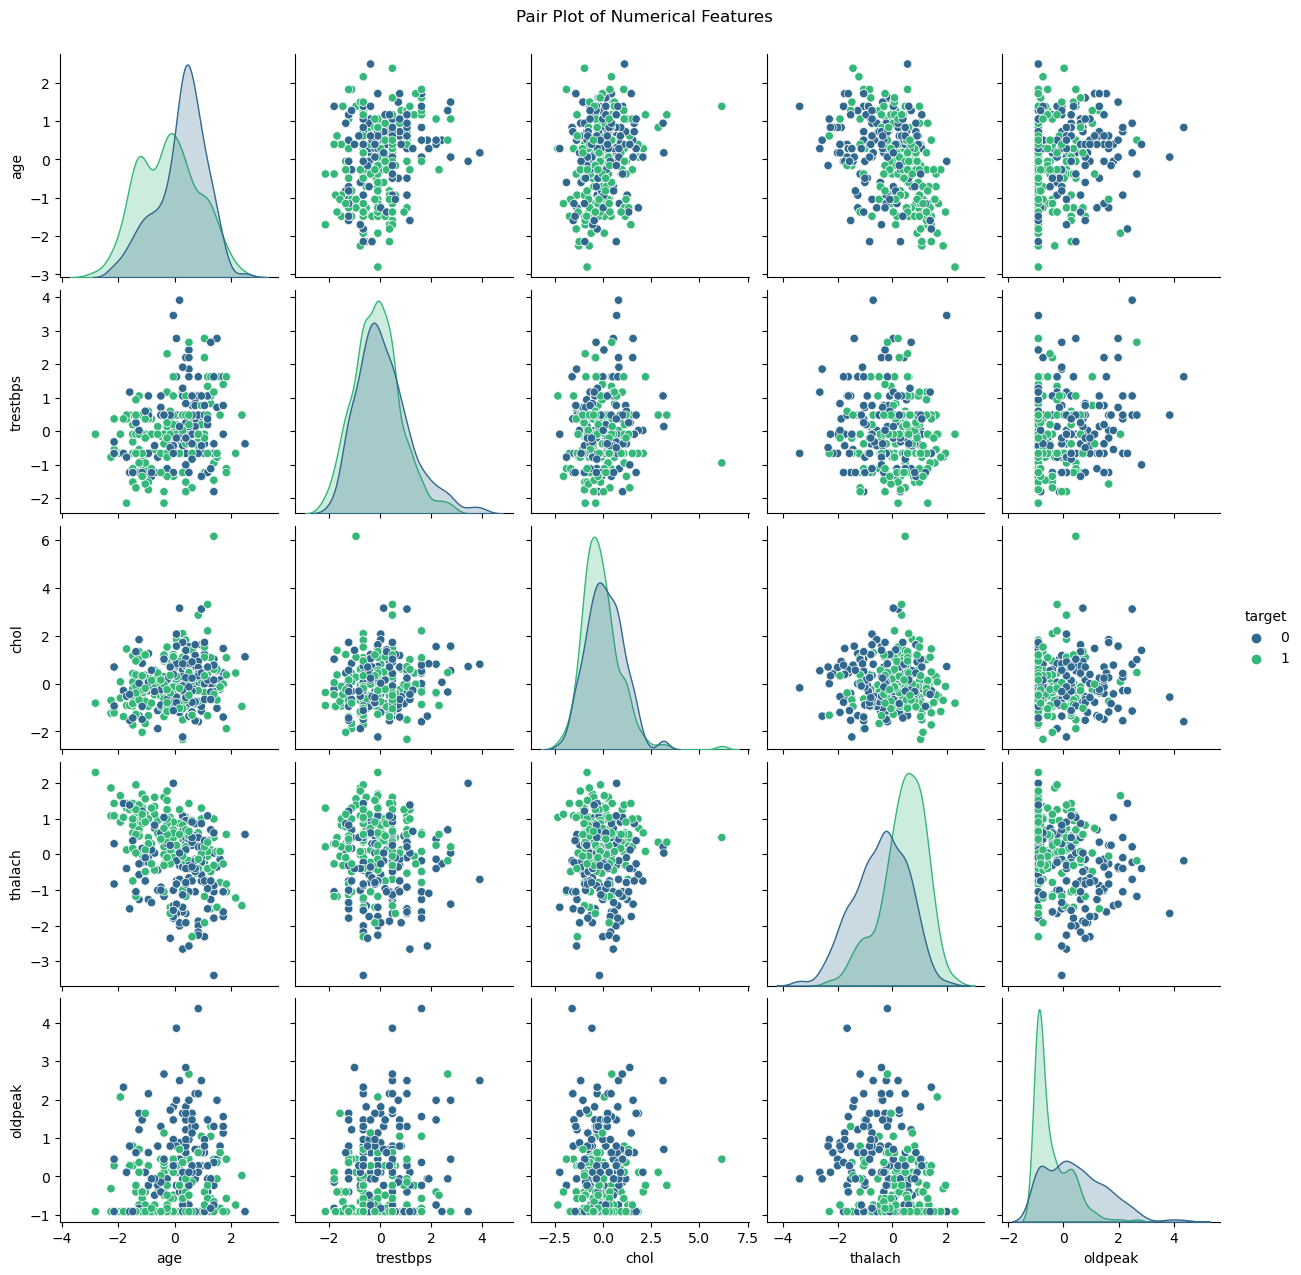

In [108]:
# Pair plot for selected features
sns.pairplot(data[numerical_features + ["target"]], hue="target", palette="viridis")
plt.suptitle("Pair Plot of Numerical Features", y=1.02)
plt.show()

In [109]:
from sklearn.model_selection import train_test_split

# Split the data into features (X) and target (y)
X = data.drop("target", axis=1)
y = data["target"]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (820, 13)
Testing set shape: (205, 13)


In [110]:
X_train.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
835,-0.599275,1,2,-0.777449,-1.881036,0,0,-1.005203,0,-0.231177,2,3,2
137,1.054918,0,0,2.763755,1.531978,0,1,0.212479,1,-0.912329,2,0,2
534,-0.047877,0,2,-1.348611,0.407235,0,0,0.777832,0,-0.912329,2,0,2
495,0.503520,1,0,0.193526,-0.232705,0,1,0.516900,0,-0.486609,1,0,3
244,-0.378716,1,2,-0.377636,-0.019392,1,0,0.734343,0,1.131129,1,0,2


In [111]:
y_test.head()

527    1
359    1
447    0
31     1
621    0
Name: target, dtype: int64

In [112]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score



In [113]:
# Initialize models
lr_model = LogisticRegression(random_state=42)
rf_model = RandomForestClassifier(random_state=42)
svm_model = SVC(random_state=42)



In [114]:
# Train and evaluate Logistic Regression
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)



In [115]:

# Train and evaluate Random Forest
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)



In [116]:
# Train and evaluate SVM
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)



In [117]:
results = {
    "Model": ["Logistic Regression", "Random Forest", "SVM"],
    "Accuracy": [accuracy_lr, accuracy_rf, accuracy_svm],
    "Precision": [precision_lr, precision_rf, precision_svm],
    "Recall": [recall_lr, recall_rf, recall_svm],
    "F1-Score": [f1_lr, f1_rf, f1_svm]
}


In [118]:

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.795122   0.756303  0.873786  0.810811
1        Random Forest  0.985366   1.000000  0.970874  0.985222
2                  SVM  0.834146   0.785124  0.922330  0.848214
